# Three-Method Corridor Generation — Oakland, CA
## 260526 Report

Generates three candidate commercial corridor layers using different spatial methodologies:
- **Method 1**: Parcel-connectivity corridors (buffer → dissolve → blob)
- **Method 2**: Seed-and-grow from BIDs / Policy Polygons
- **Method 3**: 50 m commercial grid (Jeong et al. 2024 inspired)

All outputs written to `data/corridors/260526_report/`.

In [1]:
# ── Cell 1: Imports ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import os
import json
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from shapely.ops import unary_union
from scipy.stats import entropy as scipy_entropy
from scipy.ndimage import label as ndimage_label
from tqdm.notebook import tqdm

print("Imports OK")
print(f"  geopandas : {gpd.__version__}")
print(f"  pandas    : {pd.__version__}")
print(f"  numpy     : {np.__version__}")

Imports OK
  geopandas : 0.14.4
  pandas    : 2.2.3
  numpy     : 2.1.1


In [17]:
# ── Cell 2: Constants and file paths ──────────────────────────────────────────

ROOT    = "../../"
OUT_DIR = ROOT + "data/corridors/260526_report/"

# ── Input paths ─────────────────────────────────────────────────────────────────
UNION_PARCELS_PATH    = ROOT + "data/corridors/parcels/parcels_union.gpkg"
USE_CODE_PARCELS_PATH = ROOT + "data/corridors/parcels/parcels_use_code_filtered.gpkg"
BIZ_PARCELS_PATH      = ROOT + "data/corridors/parcels/parcels_with_business.gpkg"
DATA_AXLE_XLSX        = ROOT + "data/business/Oakland_DataAxleV2.xlsx"
BIDS_SHP              = ROOT + "data/corridors/OAK_BIDs/OAK_BIDs.shp"
POLICY_SHP            = ROOT + "data/corridors/Policy_Polygons/Policy_Polygons.shp"
CITY_LIMITS_SHP       = ROOT + "data/geo/OaklandCityLimits/OaklandCityLimits.shp"

# ── Column names (configurable) ─────────────────────────────────────────────────
PARCEL_ID_COL               = "APN"
USECODE_COL                 = "UseCode_str"
USECODE_COMMERCIAL_FLAG_COL = "is_use_code_commercial"   # derived at load time
DA_OVERLAP_FLAG_COL         = "is_da_overlap"            # derived at load time
NAICS_COL                   = "Primary NAICS"
BID_NAME_COL                = "BID"
POLICY_NAME_COL             = "PP_Name"

# ── Coordinate reference systems ────────────────────────────────────────────────
WORK_CRS     = "EPSG:32610"   # UTM Zone 10N — used for all distance/area calculations
INPUT_CRS    = "EPSG:3857"    # Web Mercator — native CRS of parcel shapefiles
DA_CRS       = "EPSG:4326"    # WGS 84 — lat/lon of the business data
CORRIDOR_CRS = "EPSG:4269"    # NAD 83 — native CRS of corridor shapefiles

# ── Method 1 parameters ─────────────────────────────────────────────────────────
M1_BUFFER_M    = 25   # parcel buffer to bridge adjacent parcels (metres)
M1_MIN_PARCELS = 15   # minimum union parcels per blob to keep

# ── Method 2 parameters ─────────────────────────────────────────────────────────
M2_BUFFER_M          = 40    # grow buffer per iteration
M2_MAX_ITER          = 20    # maximum grow iterations per seed
M2_MAX_NEW_CORRIDORS = 20    # cap on randomly-seeded new corridors
M2_MIN_SEED_PARCELS  = 5     # minimum nearby parcels for a viable random seed
M2_RNG_SEED          = 42    # reproducible random seed

# ── Method 3 parameters ─────────────────────────────────────────────────────────
M3_GRID_SIZE_M            = 50    # grid cell size (metres)
M3_MIN_CELLS              = 10    # drop components with <= this many cells
M3_ACTIVE_DA_THRESH       = 1     # n_data_axle >= this → active cell
M3_ACTIVE_COMMERCIAL_THRESH = 0.25  # share_cell_commercial >= this → active cell

# ── NAICS 2-digit industry groups ───────────────────────────────────────────────
NAICS2_RETAIL_FOOD         = {44, 45, 72}
NAICS2_OFFICE_PROFESSIONAL = {51, 52, 53, 54, 55, 56}
NAICS2_INDUSTRIAL_LOGISTICS = {31, 32, 33, 48, 49}

print("Constants set.")
print(f"  Working CRS     : {WORK_CRS}")
print(f"  Output directory: {OUT_DIR}")
print(f"  M1_BUFFER_M={M1_BUFFER_M}m  M1_MIN_PARCELS={M1_MIN_PARCELS}")
print(f"  M3_MIN_CELLS={M3_MIN_CELLS}")

Constants set.
  Working CRS     : EPSG:32610
  Output directory: ../../data/corridors/260526_report/
  M1_BUFFER_M=25m  M1_MIN_PARCELS=15
  M3_MIN_CELLS=10


In [3]:
# ── Cell 3: Load input data ────────────────────────────────────────────────────

# Union parcels
print("Loading union parcels...")
union_parcels = gpd.read_file(UNION_PARCELS_PATH)
print(f"  {len(union_parcels):,} parcels  |  CRS: {union_parcels.crs}")

# Use-code parcel APNs (to derive is_use_code_commercial flag)
print("Loading use-code parcel APNs...")
_uc = gpd.read_file(USE_CODE_PARCELS_PATH, columns=[PARCEL_ID_COL])
use_code_apns = set(_uc[PARCEL_ID_COL].dropna())
print(f"  {len(use_code_apns):,} use-code APNs")

# Business-overlap parcel APNs (to derive is_da_overlap flag)
print("Loading business-overlap parcel APNs...")
_biz = gpd.read_file(BIZ_PARCELS_PATH, columns=[PARCEL_ID_COL])
biz_apns = set(_biz[PARCEL_ID_COL].dropna())
print(f"  {len(biz_apns):,} Data Axle overlap APNs")

# Data Axle businesses — load only the columns we need
print("Loading Data Axle businesses (Excel — this may take a moment)...")
_da_cols = ["Company Name", NAICS_COL, "Primary NAICS Description", "Latitude", "Longitude"]
_da_raw  = pd.read_excel(DATA_AXLE_XLSX, usecols=_da_cols)
_da_raw  = _da_raw.dropna(subset=["Latitude", "Longitude"])
data_axle_gdf = gpd.GeoDataFrame(
    _da_raw,
    geometry=gpd.points_from_xy(_da_raw["Longitude"], _da_raw["Latitude"]),
    crs=DA_CRS,
)
print(f"  {len(data_axle_gdf):,} businesses with valid coordinates")

# BIDs and policy polygons
print("Loading corridor shapefiles...")
bids   = gpd.read_file(BIDS_SHP)
_pol   = gpd.read_file(POLICY_SHP)
policy = _pol[[POLICY_NAME_COL, "geometry"]].copy()   # drop join-artifact columns
print(f"  BIDs: {len(bids)}  |  Policy polygons: {len(policy)}")

Loading union parcels...
  18,365 parcels  |  CRS: EPSG:3857
Loading use-code parcel APNs...
  5,343 use-code APNs
Loading business-overlap parcel APNs...
  15,765 Data Axle overlap APNs
Loading Data Axle businesses (Excel — this may take a moment)...
  29,545 businesses with valid coordinates
Loading corridor shapefiles...
  BIDs: 11  |  Policy polygons: 9


In [4]:
# ── Cell 4: CRS standardisation and derive parcel flags ───────────────────────

print(f"Reprojecting all layers to {WORK_CRS}...")
union_parcels = union_parcels.to_crs(WORK_CRS)
bids          = bids.to_crs(WORK_CRS)
policy        = policy.to_crs(WORK_CRS)
data_axle_gdf = data_axle_gdf.to_crs(WORK_CRS)

# Clip Data Axle businesses to the union-parcel bounding box (+ 500 m safety margin)
_oakland_bbox = box(*union_parcels.total_bounds).buffer(500)
data_axle_gdf = data_axle_gdf[data_axle_gdf.within(_oakland_bbox)].copy().reset_index(drop=True)
print(f"  Data Axle businesses within Oakland extent : {len(data_axle_gdf):,}")

# Derive is_use_code_commercial: parcel exists in the use-code filtered layer
union_parcels[USECODE_COMMERCIAL_FLAG_COL] = union_parcels[PARCEL_ID_COL].isin(use_code_apns)
print(f"  is_use_code_commercial : {union_parcels[USECODE_COMMERCIAL_FLAG_COL].sum():,} parcels")

# Derive is_da_overlap: parcel exists in the business-overlap layer
union_parcels[DA_OVERLAP_FLAG_COL] = union_parcels[PARCEL_ID_COL].isin(biz_apns)
print(f"  is_da_overlap          : {union_parcels[DA_OVERLAP_FLAG_COL].sum():,} parcels")

# Reset to a clean 0-based integer index for reliable sindex lookups
union_parcels = union_parcels.reset_index(drop=True)

print(f"\nAll layers ready in {WORK_CRS}")
print(f"  union_parcels  : {len(union_parcels):,} parcels")
print(f"  data_axle_gdf  : {len(data_axle_gdf):,} businesses")
print(f"  bids           : {len(bids)} BID polygons")
print(f"  policy         : {len(policy)} policy polygons")

Reprojecting all layers to EPSG:32610...
  Data Axle businesses within Oakland extent : 29,541
  is_use_code_commercial : 5,346 parcels
  is_da_overlap          : 15,857 parcels

All layers ready in EPSG:32610
  union_parcels  : 18,365 parcels
  data_axle_gdf  : 29,541 businesses
  bids           : 11 BID polygons
  policy         : 9 policy polygons


In [18]:
# ── Cell 4b: Load and reproject Oakland city limits ───────────────────────────

city_limits = gpd.read_file(CITY_LIMITS_SHP).to_crs(WORK_CRS)
print(f"City limits: {len(city_limits)} polygon(s)  |  CRS: {city_limits.crs}")

City limits: 1 polygon(s)  |  CRS: EPSG:32610


In [5]:
# ── Cell 5: Shared helper functions ───────────────────────────────────────────

def minmax_scale_series(s: pd.Series) -> pd.Series:
    """Min-max scale a numeric series to [0, 1]. Returns 0.0 if constant."""
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - mn) / (mx - mn)


def zscore_series(s: pd.Series) -> pd.Series:
    """Z-score normalise. Returns 0.0 if std is zero."""
    std = s.std()
    if std == 0:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - s.mean()) / std


def log1p_transform(s: pd.Series) -> pd.Series:
    """Apply log(1 + x) to a non-negative numeric series."""
    return np.log1p(s.clip(lower=0))


def naics_diversity(naics_series: pd.Series) -> float:
    """Shannon entropy (bits) of the 4-digit NAICS distribution. Returns 0 if empty."""
    codes = naics_series.dropna().astype(str).str[:4]
    if codes.empty:
        return 0.0
    probs = codes.value_counts() / len(codes)
    return float(scipy_entropy(probs, base=2))


def compute_template_sizes(bids_gdf: gpd.GeoDataFrame,
                            policy_gdf: gpd.GeoDataFrame) -> dict:
    """
    Compute area percentiles from the combined BID + policy polygon layer.
    Returns a dict with keys: p25, p50, p75, p90, iqr, median (all in m²).
    """
    areas = pd.concat([
        bids_gdf.geometry.area,
        policy_gdf.geometry.area,
    ]).reset_index(drop=True)
    p25 = float(areas.quantile(0.25))
    p50 = float(areas.quantile(0.50))
    p75 = float(areas.quantile(0.75))
    p90 = float(areas.quantile(0.90))
    return {
        "p25": p25, "p50": p50, "p75": p75, "p90": p90,
        "iqr": p75 - p25, "median": p50,
        "areas": areas,
    }


# Pre-compute template sizes (used by Methods 1 and 2)
template_sizes = compute_template_sizes(bids, policy)

print("Template sizes (BIDs + Policy polygons combined):")
for k, v in template_sizes.items():
    if k != "areas":
        print(f"  {k:>8} : {v:>12,.0f} m²   ({v / 10_000:6.2f} ha)")

print("\nHelper functions defined.")

Template sizes (BIDs + Policy polygons combined):
       p25 :      266,994 m²   ( 26.70 ha)
       p50 :      448,566 m²   ( 44.86 ha)
       p75 :      606,745 m²   ( 60.67 ha)
       p90 :    1,194,069 m²   (119.41 ha)
       iqr :      339,751 m²   ( 33.98 ha)
    median :      448,566 m²   ( 44.86 ha)

Helper functions defined.


In [13]:
# ── Cell 6: Shared summary functions ──────────────────────────────────────────

def compute_parcel_summary(corridors_gdf: gpd.GeoDataFrame,
                            union_parcels: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    For each corridor, count union parcels and optional flag subsets.
    Uses parcel centroids for fast 'within' joins.
    Returns a DataFrame indexed by corridor_id.
    """
    # Build centroid layer with only required columns
    keep = ["geometry", PARCEL_ID_COL, USECODE_COL]
    for col in [USECODE_COMMERCIAL_FLAG_COL, DA_OVERLAP_FLAG_COL]:
        if col in union_parcels.columns:
            keep.append(col)
    centroids = union_parcels[keep].copy()
    centroids["geometry"] = union_parcels.geometry.centroid

    joined = gpd.sjoin(
        centroids,
        corridors_gdf[["corridor_id", "geometry"]],
        how="inner", predicate="within",
    )

    rows = []
    for cid, grp in joined.groupby("corridor_id"):
        row = {"corridor_id": cid, "n_union_parcels": len(grp)}
        if USECODE_COMMERCIAL_FLAG_COL in grp.columns:
            row["n_use_code_commercial"] = int(grp[USECODE_COMMERCIAL_FLAG_COL].sum())
        if DA_OVERLAP_FLAG_COL in grp.columns:
            row["n_da_overlap"] = int(grp[DA_OVERLAP_FLAG_COL].sum())
        dist = grp[USECODE_COL].dropna().value_counts().head(20).to_dict()
        row["usecode_distribution"] = json.dumps({str(k): int(v) for k, v in dist.items()})
        rows.append(row)
    return pd.DataFrame(rows).set_index("corridor_id") if rows else pd.DataFrame()


def compute_business_summary(corridors_gdf: gpd.GeoDataFrame,
                              da_gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    For each corridor, count Data Axle businesses and compute NAICS statistics.
    Returns a DataFrame indexed by corridor_id.
    """
    joined = gpd.sjoin(
        da_gdf[["geometry", NAICS_COL]],
        corridors_gdf[["corridor_id", "geometry"]],
        how="inner", predicate="within",
    )

    rows = []
    for cid, grp in joined.groupby("corridor_id"):
        naics_s  = grp[NAICS_COL].dropna()
        naics2_s = naics_s.astype(str).str[:2]

        n_retail   = int(naics2_s.isin([str(x) for x in NAICS2_RETAIL_FOOD]).sum())
        n_office   = int(naics2_s.isin([str(x) for x in NAICS2_OFFICE_PROFESSIONAL]).sum())
        n_industrl = int(naics2_s.isin([str(x) for x in NAICS2_INDUSTRIAL_LOGISTICS]).sum())

        dist = naics_s.astype(str).str[:4].value_counts().head(20).to_dict()
        rows.append({
            "corridor_id"           : cid,
            "n_da_businesses"       : len(grp),
            "naics_distribution"    : json.dumps({str(k): int(v) for k, v in dist.items()}),
            "n_unique_naics4"       : int(naics_s.astype(str).str[:4].nunique()),
            "naics_diversity"       : round(naics_diversity(naics_s), 4),
            "n_retail_food_services": n_retail,
            "n_office_professional" : n_office,
            "n_industrial_logistics": n_industrl,
        })
    return pd.DataFrame(rows).set_index("corridor_id") if rows else pd.DataFrame()


def compute_overlap_summary(corridors_gdf: gpd.GeoDataFrame,
                             bids_gdf: gpd.GeoDataFrame,
                             policy_gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    For each corridor, compute area overlap with BIDs and policy polygons.
    Returns a DataFrame indexed by corridor_id.
    """
    bids_union   = unary_union(bids_gdf.geometry)
    policy_union = unary_union(policy_gdf.geometry)

    rows = []
    for _, corr in corridors_gdf.iterrows():
        cid    = corr["corridor_id"]
        c_geom = corr["geometry"]
        c_area = c_geom.area if c_geom and not c_geom.is_empty else 0.0

        bid_isect  = c_geom.intersection(bids_union)   if c_area > 0 else None
        pol_isect  = c_geom.intersection(policy_union) if c_area > 0 else None
        bid_area   = bid_isect.area  if bid_isect  and not bid_isect.is_empty  else 0.0
        pol_area   = pol_isect.area  if pol_isect  and not pol_isect.is_empty  else 0.0

        rows.append({
            "corridor_id"            : cid,
            "bid_overlap_area_m2"    : round(bid_area, 1),
            "policy_overlap_area_m2" : round(pol_area, 1),
            "bid_overlap_share"      : round(bid_area / c_area, 4) if c_area > 0 else 0.0,
            "policy_overlap_share"   : round(pol_area / c_area, 4) if c_area > 0 else 0.0,
        })
    return pd.DataFrame(rows).set_index("corridor_id") if rows else pd.DataFrame()


def build_corridor_attributes(corridors_gdf: gpd.GeoDataFrame,
                               union_parcels: gpd.GeoDataFrame,
                               da_gdf: gpd.GeoDataFrame,
                               bids_gdf: gpd.GeoDataFrame,
                               policy_gdf: gpd.GeoDataFrame,
                               method: str) -> gpd.GeoDataFrame:
    """
    Attach all summary attributes to a corridor GeoDataFrame.
    Input GDF must have a 'corridor_id' column.
    Returns the corridors GDF with added summary columns.
    """
    print(f"  Parcel summaries...")
    p_sum = compute_parcel_summary(corridors_gdf, union_parcels)

    print(f"  Business summaries...")
    b_sum = compute_business_summary(corridors_gdf, da_gdf)

    print(f"  Overlap summaries...")
    o_sum = compute_overlap_summary(corridors_gdf, bids_gdf, policy_gdf)

    result = corridors_gdf.copy().set_index("corridor_id")
    result["method"]  = method
    result["area_m2"] = result.geometry.area.round(1)
    result["area_ha"] = (result.geometry.area / 10_000).round(4)

    # Drop columns that will be provided by summary joins (avoids merge conflicts)
    incoming_cols = set()
    for df in [p_sum, b_sum, o_sum]:
        if not df.empty:
            incoming_cols.update(df.columns.tolist())
    result = result.drop(columns=[c for c in incoming_cols if c in result.columns],
                          errors="ignore")

    for df in [p_sum, b_sum, o_sum]:
        if not df.empty:
            result = result.join(df, how="left")

    # Coerce count columns to int (fill NaN → 0)
    int_cols = ["n_union_parcels", "n_use_code_commercial", "n_da_overlap",
                "n_da_businesses", "n_unique_naics4",
                "n_retail_food_services", "n_office_professional", "n_industrial_logistics"]
    for col in int_cols:
        if col in result.columns:
            result[col] = result[col].fillna(0).astype(int)

    return result.reset_index()


def print_sanity_check(corridors_gdf: gpd.GeoDataFrame, method_name: str):
    """Print standard sanity-check stats for a corridor layer."""
    sep = "=" * 58
    print(f"\n{sep}")
    print(f"  Sanity check — {method_name}")
    print(sep)
    print(f"  Corridors        : {len(corridors_gdf):>8,}")
    if "area_m2" in corridors_gdf.columns:
        print(f"  Total area       : {corridors_gdf['area_m2'].sum():>14,.0f} m²"
              f"  ({corridors_gdf['area_m2'].sum() / 1e6:.2f} km²)")
        print(f"  Median area      : {corridors_gdf['area_m2'].median():>14,.0f} m²"
              f"  ({corridors_gdf['area_m2'].median() / 10_000:.2f} ha)")
    if "n_union_parcels" in corridors_gdf.columns:
        print(f"  Union parcels    : {int(corridors_gdf['n_union_parcels'].sum()):>8,}")
    if "n_da_businesses" in corridors_gdf.columns:
        print(f"  DA businesses    : {int(corridors_gdf['n_da_businesses'].sum()):>8,}")
    print(f"{sep}\n")


print("Summary functions defined.")

Summary functions defined.


---
## Method 1 — Parcel-Connectivity Corridors

**Intuition:** Where does commercial land actually sit as a connected spatial fabric?

**Algorithm:** Buffer each union parcel by 40 m → dissolve overlapping buffers → explode to individual blobs → negative-buffer to restore original shapes → filter by minimum parcel count → tag each blob with a size class relative to the BID/policy polygon size distribution.

In [19]:
# ── Cell 7: Method 1 — Parcel-Connectivity Corridors ──────────────────────────

def method1_parcel_connectivity(
    union_parcels: gpd.GeoDataFrame,
    buffer_m: float = M1_BUFFER_M,
    min_parcels: int = M1_MIN_PARCELS,
    template_sizes: dict | None = None,
) -> gpd.GeoDataFrame:
    """
    Build corridors by buffering union parcels, dissolving connected blobs,
    and tagging each blob with a size class.

    Returns a GeoDataFrame with columns: corridor_id, size_class, geometry.
    """
    print("Method 1 — Parcel-connectivity corridors")

    # 1. Buffer each parcel geometry
    print(f"  Buffering {len(union_parcels):,} parcels by {buffer_m} m ...")
    buffered_geoms = union_parcels.geometry.buffer(buffer_m)
    buffered_gdf   = gpd.GeoDataFrame(geometry=buffered_geoms, crs=union_parcels.crs)

    # 2. Dissolve → explode → individual connected blobs
    print("  Dissolving and exploding into blobs ...")
    blobs = (
        buffered_gdf
        .dissolve()
        .explode(index_parts=False)
        .reset_index(drop=True)
    )

    # 3. Negative-buffer to undo the expansion (restores approximate original shapes)
    print("  Restoring shapes with negative buffer ...")
    blobs["geometry"] = blobs.geometry.buffer(-buffer_m)
    blobs = blobs[~blobs.geometry.is_empty & blobs.geometry.is_valid].reset_index(drop=True)

    blobs["corridor_id"] = [f"M1_{i:04d}" for i in range(len(blobs))]
    blobs = blobs[["corridor_id", "geometry"]].copy()

    # 4. Count union parcel centroids per blob to support minimum-parcel filter
    print("  Counting parcels per blob ...")
    parcel_pts = union_parcels[["geometry"]].copy()
    parcel_pts["geometry"] = union_parcels.geometry.centroid

    cnt_join   = gpd.sjoin(parcel_pts, blobs[["corridor_id", "geometry"]],
                            how="inner", predicate="within")
    cnt_series = cnt_join.groupby("corridor_id").size().rename("_n_parcels")
    blobs      = blobs.join(cnt_series, on="corridor_id", how="left")
    blobs["_n_parcels"] = blobs["_n_parcels"].fillna(0).astype(int)

    # 5. Filter by minimum parcel count
    print(f"  Removing blobs with < {min_parcels} parcels ...")
    print(f"    Before filter : {len(blobs):,} blobs")
    blobs = blobs[blobs["_n_parcels"] >= min_parcels].drop(columns=["_n_parcels"])
    blobs = blobs.reset_index(drop=True)
    blobs["corridor_id"] = [f"M1_{i:04d}" for i in range(len(blobs))]
    print(f"    After filter  : {len(blobs):,} blobs")

    # 6. Tag size class based on BID/policy polygon size distribution
    if template_sizes:
        areas  = blobs.geometry.area
        p75    = template_sizes["p75"]
        p90    = template_sizes["p90"]
        median = template_sizes["median"]

        blobs["size_class"] = "Normal"
        blobs.loc[areas > p75,                             "size_class"] = "Large"
        blobs.loc[(areas > 2 * median) | (areas > p90),   "size_class"] = "Very large / corridor complex"
    else:
        blobs["size_class"] = "Unknown"

    print(f"\n  Result: {len(blobs)} corridor blobs")
    print(blobs["size_class"].value_counts().to_string())
    return blobs


# ── Run Method 1 ───────────────────────────────────────────────────────────────
m1_raw = method1_parcel_connectivity(
    union_parcels,
    buffer_m=M1_BUFFER_M,
    min_parcels=M1_MIN_PARCELS,
    template_sizes=template_sizes,
)

Method 1 — Parcel-connectivity corridors
  Buffering 18,365 parcels by 25 m ...
  Dissolving and exploding into blobs ...
  Restoring shapes with negative buffer ...
  Counting parcels per blob ...
  Removing blobs with < 15 parcels ...
    Before filter : 1,481 blobs
    After filter  : 73 blobs

  Result: 73 corridor blobs
size_class
Normal                           63
Very large / corridor complex     7
Large                             3


Building Method 1 full attribute table...
  Parcel summaries...
  Business summaries...
  Overlap summaries...

  Sanity check — Method 1 — Parcel-Connectivity
  Corridors        :       73
  Total area       :     25,851,744 m²  (25.85 km²)
  Median area      :         53,442 m²  (5.34 ha)
  Union parcels    :   15,602
  DA businesses    :   22,971

Size-class breakdown:
size_class
Normal                           63
Very large / corridor complex     7
Large                             3

Top 10 corridors by DA business count:
corridor_id  area_ha  n_union_parcels  n_use_code_commercial  n_da_overlap  n_da_businesses  naics_diversity  bid_overlap_share  policy_overlap_share                    size_class
    M1_0009 585.9246             6002                   2130          5147            10090           5.5749             0.2974                0.2643 Very large / corridor complex
    M1_0014 262.2514             1345                    418          1204             3698           4.24

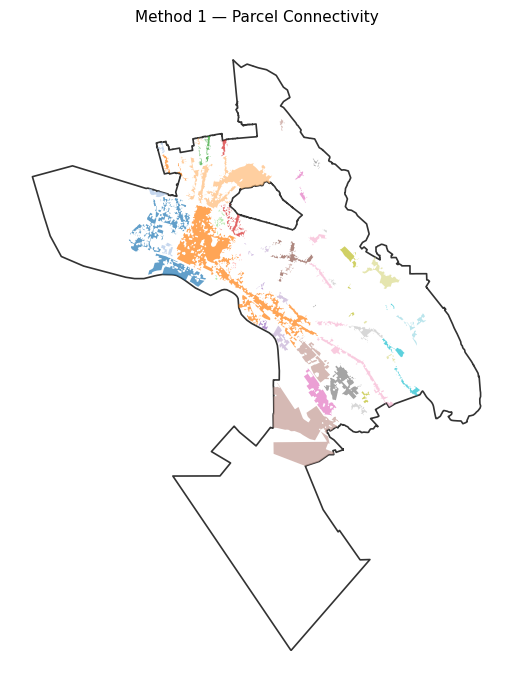

In [20]:
# ── Cell 8: Method 1 — Attach attributes, sanity check, map ───────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm

print("Building Method 1 full attribute table...")
m1_corridors = build_corridor_attributes(
    m1_raw, union_parcels, data_axle_gdf, bids, policy, method="method_1_parcel_connectivity"
)

# Preserve the size_class flag computed by the method
sc_map = m1_raw.set_index("corridor_id")["size_class"]
m1_corridors["size_class"] = m1_corridors["corridor_id"].map(sc_map)

# Sanity check
print_sanity_check(m1_corridors, "Method 1 — Parcel-Connectivity")

print("Size-class breakdown:")
print(m1_corridors["size_class"].value_counts().to_string())

print("\nTop 10 corridors by DA business count:")
preview_cols = ["corridor_id", "area_ha", "n_union_parcels",
                "n_use_code_commercial", "n_da_overlap", "n_da_businesses",
                "naics_diversity", "bid_overlap_share", "policy_overlap_share", "size_class"]
available = [c for c in preview_cols if c in m1_corridors.columns]
print(
    m1_corridors.nlargest(10, "n_da_businesses")[available]
    .to_string(index=False)
)

# ── Quick-look map ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
city_limits.plot(ax=ax, facecolor="none", edgecolor="#333333", linewidth=1.2)
m1_corridors["_color_idx"] = range(len(m1_corridors))
m1_corridors.plot(ax=ax, column="_color_idx", cmap="tab20",
                  alpha=0.7, edgecolor="none", legend=False)
m1_corridors.drop(columns=["_color_idx"], inplace=True)
ax.set_axis_off()
ax.set_title("Method 1 — Parcel Connectivity", fontsize=11)
plt.tight_layout()
plt.show()

---
## Method 2 — Seed-and-Grow from BIDs / Policy Polygons

**Intuition:** If known BIDs and policy polygons are examples of what Oakland partners mean by "corridor," can we grow similar corridor geographies elsewhere?

**Algorithm:**
1. Combine BIDs + policy polygons into a seed layer.
2. Grow each seed by buffering 40 m and absorbing nearby unassigned union parcels until the blob area ≥ 50th-percentile template size (~45 ha).
3. Randomly seed new corridors from unassigned parcels and grow them the same way, until `MAX_NEW_CORRIDORS` or no more viable clusters.

Randomness is reproducible with `RNG_SEED = 42`.

In [21]:
# ── Cell 9: Method 2 — Seed-and-Grow from BIDs / Policy Polygons ──────────────

def prepare_seed_layer(bids_gdf: gpd.GeoDataFrame,
                        policy_gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Combine BIDs and policy polygons into a single seed layer."""
    bid_seeds             = bids_gdf[["geometry"]].copy()
    bid_seeds["seed_name"]   = bids_gdf[BID_NAME_COL].astype(str).values
    bid_seeds["seed_source"] = "BID"

    pol_seeds                = policy_gdf[["geometry"]].copy()
    pol_seeds["seed_name"]   = policy_gdf[POLICY_NAME_COL].astype(str).values
    pol_seeds["seed_source"] = "Policy"

    seeds = gpd.GeoDataFrame(
        pd.concat([bid_seeds, pol_seeds], ignore_index=True),
        crs=bids_gdf.crs,
    )
    return seeds


def grow_one_seed(seed_geom, avail_gdf_reset: gpd.GeoDataFrame,
                  target_area: float,
                  buffer_m: float = 40, max_iter: int = 20):
    """
    Grow seed_geom by iteratively absorbing nearby union parcels.

    Parameters
    ----------
    avail_gdf_reset : GeoDataFrame with a clean 0-based positional index.
    target_area     : m² — stop growing once blob area reaches this.

    Returns
    -------
    grown_geom : Shapely geometry
    absorbed   : list of positional indices absorbed from avail_gdf_reset
    """
    if avail_gdf_reset.empty:
        return seed_geom, []

    current_geom = seed_geom
    absorbed     = []
    remaining    = np.ones(len(avail_gdf_reset), dtype=bool)
    sindex       = avail_gdf_reset.sindex

    for _ in range(max_iter):
        buffered  = current_geom.buffer(buffer_m)
        cand_pos  = [p for p in sindex.intersection(buffered.bounds) if remaining[p]]

        if not cand_pos:
            break

        cands         = avail_gdf_reset.iloc[cand_pos]
        touching_mask = cands.intersects(buffered).values
        touching_pos  = [cand_pos[i] for i, m in enumerate(touching_mask) if m]

        if not touching_pos:
            break

        geoms        = [current_geom] + avail_gdf_reset.iloc[touching_pos].geometry.tolist()
        current_geom = unary_union(geoms)
        absorbed.extend(touching_pos)
        for p in touching_pos:
            remaining[p] = False

        if current_geom.area >= target_area:
            break

    return current_geom, absorbed


def run_seed_and_grow(seed_layer: gpd.GeoDataFrame,
                      union_parcels_gdf: gpd.GeoDataFrame,
                      target_area: float,
                      buffer_m: int  = M2_BUFFER_M,
                      max_iter: int  = M2_MAX_ITER,
                      max_new: int   = M2_MAX_NEW_CORRIDORS,
                      min_seed: int  = M2_MIN_SEED_PARCELS,
                      rng_seed: int  = M2_RNG_SEED) -> gpd.GeoDataFrame:
    """
    Grow existing BID/policy seeds, then randomly seed new corridors.
    Returns a GeoDataFrame of grown corridors.
    """
    rng = np.random.default_rng(rng_seed)
    grown_corridors   = []
    assigned_orig_idx = set()   # original DataFrame indices already assigned

    # ── Phase 1: Grow from existing BID / policy seeds ────────────────────────
    print(f"  Phase 1: growing {len(seed_layer)} existing seeds...")
    for _, row in tqdm(seed_layer.iterrows(), total=len(seed_layer), leave=False):
        avail          = union_parcels_gdf.loc[
                            ~union_parcels_gdf.index.isin(assigned_orig_idx)].copy()
        orig_idx_list  = avail.index.tolist()
        avail_reset    = avail.reset_index(drop=True)

        grown_geom, used_pos = grow_one_seed(
            row.geometry, avail_reset, target_area, buffer_m, max_iter
        )
        used_orig = [orig_idx_list[p] for p in used_pos]
        assigned_orig_idx.update(used_orig)

        grown_corridors.append({
            "seed_name"  : row["seed_name"],
            "seed_source": row["seed_source"],
            "geometry"   : grown_geom,
        })

    # ── Phase 2: Randomly seed new corridors ──────────────────────────────────
    print(f"  Phase 2: seeding new corridors (max {max_new})...")
    n_new      = 0
    n_attempts = 0
    max_attempts = max_new * 15    # safety cap to prevent infinite loop

    while n_new < max_new and n_attempts < max_attempts:
        n_attempts += 1
        avail = union_parcels_gdf.loc[
                    ~union_parcels_gdf.index.isin(assigned_orig_idx)].copy()

        if len(avail) < min_seed:
            print(f"    Only {len(avail)} parcels left — stopping.")
            break

        # Pick a random unassigned parcel as candidate seed centre
        seed_row     = avail.sample(1, random_state=int(rng.integers(0, 2**31))).iloc[0]
        search_buf   = seed_row.geometry.centroid.buffer(buffer_m * 3)
        nearby_pos   = list(avail.sindex.intersection(search_buf.bounds))
        nearby       = avail.iloc[nearby_pos]
        nearby       = nearby[nearby.intersects(search_buf)]

        if len(nearby) < min_seed:
            # Isolated parcel — mark used and move on
            assigned_orig_idx.add(seed_row.name)
            continue

        seed_geom      = unary_union(nearby.geometry.tolist())
        orig_idx_list  = avail.index.tolist()
        avail_reset    = avail.reset_index(drop=True)

        grown_geom, used_pos = grow_one_seed(
            seed_geom, avail_reset, target_area, buffer_m, max_iter
        )
        used_orig = [orig_idx_list[p] for p in used_pos]

        if len(used_pos) < min_seed:
            assigned_orig_idx.update(used_orig)
            continue

        assigned_orig_idx.update(used_orig)
        grown_corridors.append({
            "seed_name"  : f"new_corridor_{n_new + 1}",
            "seed_source": "random_seed",
            "geometry"   : grown_geom,
        })
        n_new += 1

    print(f"  Total: {len(seed_layer)} grown seeds + {n_new} new random corridors")

    gdf = gpd.GeoDataFrame(grown_corridors, crs=union_parcels_gdf.crs)
    gdf["corridor_id"] = [f"M2_{i:04d}" for i in range(len(gdf))]
    return gdf[["corridor_id", "seed_name", "seed_source", "geometry"]]


def enforce_non_overlapping(corridors_gdf: gpd.GeoDataFrame,
                             priority_col: str = "seed_source") -> gpd.GeoDataFrame:
    """
    Clip corridor geometries so no two corridors overlap.

    Priority order (BID first, then Policy, then random_seed — within each
    group the row order is preserved).  Each corridor has any area claimed by
    a higher-priority corridor subtracted from it.

    Returns a GeoDataFrame with exclusive (non-overlapping) geometries.
    Any corridor that becomes empty after clipping is dropped.
    """
    priority_map = {"BID": 0, "Policy": 1, "random_seed": 2}
    gdf = corridors_gdf.copy()
    gdf["_priority"] = gdf[priority_col].map(priority_map).fillna(99).astype(int)
    gdf = gdf.sort_values(["_priority", "corridor_id"]).reset_index(drop=True)

    claimed  = None   # running union of all placed corridors
    new_geoms = []

    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            new_geoms.append(None)
            continue

        if claimed is not None and not claimed.is_empty:
            geom = geom.difference(claimed)

        if geom is None or geom.is_empty:
            new_geoms.append(None)
        else:
            new_geoms.append(geom)
            claimed = geom if claimed is None else claimed.union(geom)

    gdf["geometry"] = new_geoms
    gdf = gdf[gdf["geometry"].notna() & ~gdf["geometry"].is_empty].copy()
    gdf = gdf.drop(columns=["_priority"]).reset_index(drop=True)
    return gdf


# ── Run Method 2 ───────────────────────────────────────────────────────────────
seed_layer = prepare_seed_layer(bids, policy)
print(f"Seed layer: {len(seed_layer)} seeds ({seed_layer['seed_source'].value_counts().to_dict()})")

target_area = template_sizes["p50"]
print(f"Target grow area (50th percentile): {target_area:,.0f} m²  ({target_area/10_000:.2f} ha)")

m2_grown = run_seed_and_grow(
    seed_layer, union_parcels, target_area,
    buffer_m=M2_BUFFER_M, max_iter=M2_MAX_ITER,
    max_new=M2_MAX_NEW_CORRIDORS, min_seed=M2_MIN_SEED_PARCELS,
    rng_seed=M2_RNG_SEED,
)
print(f"\nAfter growing: {len(m2_grown)} corridors")

# Enforce spatial exclusivity (BID > Policy > random_seed)
print("Enforcing non-overlapping geometries (BID > Policy > random_seed)...")
m2_raw = enforce_non_overlapping(m2_grown, priority_col="seed_source")
# Re-assign clean sequential IDs after any empty corridors are dropped
m2_raw["corridor_id"] = [f"M2_{i:04d}" for i in range(len(m2_raw))]
print(f"After non-overlapping: {len(m2_raw)} corridors remain")
print(f"\nMethod 2 raw corridors: {len(m2_raw)}")

Seed layer: 20 seeds ({'BID': 11, 'Policy': 9})
Target grow area (50th percentile): 448,566 m²  (44.86 ha)
  Phase 1: growing 20 existing seeds...


  0%|          | 0/20 [00:00<?, ?it/s]

  Phase 2: seeding new corridors (max 20)...
  Total: 20 grown seeds + 20 new random corridors

After growing: 40 corridors
Enforcing non-overlapping geometries (BID > Policy > random_seed)...
After non-overlapping: 39 corridors remain

Method 2 raw corridors: 39


Building Method 2 full attribute table...
  Parcel summaries...
  Business summaries...
  Overlap summaries...

  Sanity check — Method 2 — Seed-and-Grow (non-overlapping)
  Corridors        :       39
  Total area       :     18,177,684 m²  (18.18 km²)
  Median area      :        129,749 m²  (12.97 ha)
  Union parcels    :   11,588
  DA businesses    :   17,315

Seed source breakdown:
seed_source
random_seed    20
BID            11
Policy          8

Top 10 corridors by DA business count:
corridor_id          seed_name seed_source  area_ha  n_union_parcels  n_da_businesses  naics_diversity  bid_overlap_share  policy_overlap_share
    M2_0000           Downtown         BID  54.7425             1764             2632           5.8259             0.8673                0.4963
    M2_0006 Temescal/Telegraph         BID  55.9728              532             2033           3.9776             0.8778                0.0000
    M2_0002       Lake Merritt         BID  68.1382              496     

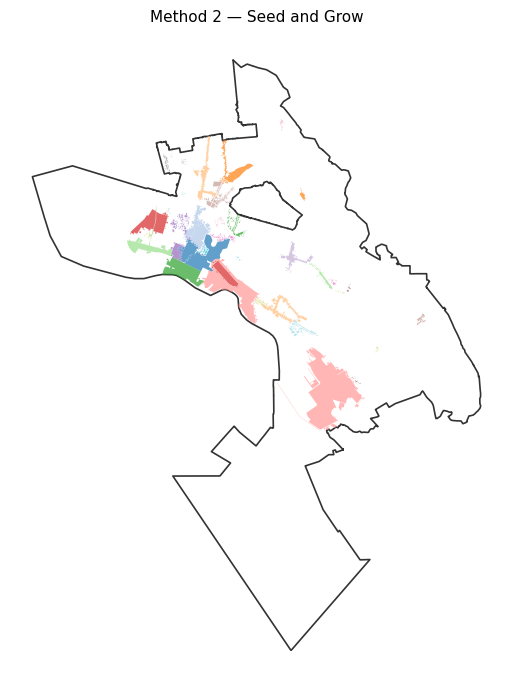

In [22]:
# ── Cell 10: Method 2 — Attach attributes, sanity check, map ──────────────────

print("Building Method 2 full attribute table...")
m2_corridors = build_corridor_attributes(
    m2_raw, union_parcels, data_axle_gdf, bids, policy,
    method="method_2_seed_and_grow",
)

# Preserve seed provenance columns
for col in ["seed_name", "seed_source"]:
    if col in m2_raw.columns:
        m2_corridors[col] = m2_raw.set_index("corridor_id")[col].reindex(
            m2_corridors["corridor_id"]
        ).values

# Sanity check
print_sanity_check(m2_corridors, "Method 2 — Seed-and-Grow (non-overlapping)")

print("Seed source breakdown:")
if "seed_source" in m2_corridors.columns:
    print(m2_corridors["seed_source"].value_counts().to_string())

print("\nTop 10 corridors by DA business count:")
preview_cols = ["corridor_id", "seed_name", "seed_source", "area_ha",
                "n_union_parcels", "n_da_businesses",
                "naics_diversity", "bid_overlap_share", "policy_overlap_share"]
available = [c for c in preview_cols if c in m2_corridors.columns]
print(m2_corridors.nlargest(10, "n_da_businesses")[available].to_string(index=False))

# ── Quick-look map ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
city_limits.plot(ax=ax, facecolor="none", edgecolor="#333333", linewidth=1.2)
m2_corridors["_color_idx"] = range(len(m2_corridors))
m2_corridors.plot(ax=ax, column="_color_idx", cmap="tab20",
                  alpha=0.7, edgecolor="none", legend=False)
m2_corridors.drop(columns=["_color_idx"], inplace=True)
ax.set_axis_off()
ax.set_title("Method 2 — Seed and Grow", fontsize=11)
plt.tight_layout()
plt.show()

---
## Method 3 — Commercial Grid (Jeong et al. 2024 inspired)

**Intuition:** Where do commercial indicators concentrate when the city is treated as a continuous surface rather than as parcels?

**Algorithm:**
1. Build a 50 m grid over the union-parcel extent.
2. Assign to each cell: `n_data_axle`, `share_cell_commercial`, `n_union_parcels`, and NAICS-group counts.
3. Normalise with `log1p` + z-scores; compute a `commercial_intensity` score.
4. Mark **active cells**: `n_data_axle ≥ 1` OR `share_cell_commercial ≥ 0.25`.
5. Detect **edge-adjacent** connected components (4-connectivity) using `scipy.ndimage.label`.
6. Dissolve by component; drop fragments with ≤ 3 cells.
7. Score corridors by scaled business count + scaled commercial area + scaled NAICS diversity.

In [23]:
# ── Cell 11: Method 3 — Commercial Grid ───────────────────────────────────────

def build_commercial_grid(
    union_parcels: gpd.GeoDataFrame,
    da_gdf: gpd.GeoDataFrame,
    cell_size_m: float = M3_GRID_SIZE_M,
    active_da_thresh: int = M3_ACTIVE_DA_THRESH,
    active_comm_thresh: float = M3_ACTIVE_COMMERCIAL_THRESH,
    min_cells: int = M3_MIN_CELLS,
) -> gpd.GeoDataFrame:
    """
    Build a 50 m commercial grid, detect edge-adjacent active-cell clusters,
    and return corridor polygons with basic cell-aggregate attributes.
    """
    print("Method 3 — Commercial grid corridors")
    crs = union_parcels.crs

    # ── 1. Build fishnet over union_parcels extent ─────────────────────────────
    print(f"  Building {cell_size_m} m grid...")
    minx, miny, maxx, maxy = union_parcels.total_bounds
    xs = np.arange(minx, maxx + cell_size_m, cell_size_m)
    ys = np.arange(miny, maxy + cell_size_m, cell_size_m)

    cells = []
    for i, y in enumerate(ys[:-1]):
        for j, x in enumerate(xs[:-1]):
            cells.append({
                "row_idx": i,
                "col_idx": j,
                "geometry": box(x, y, x + cell_size_m, y + cell_size_m),
            })
    grid = gpd.GeoDataFrame(cells, crs=crs).reset_index().rename(columns={"index": "cell_id"})
    print(f"    Total grid cells: {len(grid):,}")

    # ── 2a. Count Data Axle businesses per cell ────────────────────────────────
    print("  Counting businesses per cell...")
    biz_join = gpd.sjoin(
        da_gdf[["geometry", NAICS_COL]],
        grid[["cell_id", "geometry"]],
        how="inner", predicate="within",
    )
    cell_biz = biz_join.groupby("cell_id").size().rename("n_data_axle")

    # NAICS group counts
    biz_join["naics2"] = biz_join[NAICS_COL].astype(str).str[:2]
    cell_retail    = (biz_join[biz_join["naics2"].isin([str(x) for x in NAICS2_RETAIL_FOOD])]
                      .groupby("cell_id").size().rename("n_retail_food_services"))
    cell_office    = (biz_join[biz_join["naics2"].isin([str(x) for x in NAICS2_OFFICE_PROFESSIONAL])]
                      .groupby("cell_id").size().rename("n_office_professional"))
    cell_industrl  = (biz_join[biz_join["naics2"].isin([str(x) for x in NAICS2_INDUSTRIAL_LOGISTICS])]
                      .groupby("cell_id").size().rename("n_industrial_logistics"))

    grid = (grid
            .join(cell_biz, on="cell_id", how="left")
            .join(cell_retail,   on="cell_id", how="left")
            .join(cell_office,   on="cell_id", how="left")
            .join(cell_industrl, on="cell_id", how="left"))
    for col in ["n_data_axle", "n_retail_food_services", "n_office_professional", "n_industrial_logistics"]:
        grid[col] = grid[col].fillna(0).astype(int)

    # ── 2b. Count union parcels per cell ──────────────────────────────────────
    print("  Counting union parcels per cell...")
    parcel_join = gpd.sjoin(
        union_parcels[["geometry"]],
        grid[["cell_id", "geometry"]],
        how="inner", predicate="intersects",
    )
    cell_parcels = parcel_join.groupby("cell_id").size().rename("n_union_parcels")
    grid = grid.join(cell_parcels, on="cell_id", how="left")
    grid["n_union_parcels"] = grid["n_union_parcels"].fillna(0).astype(int)

    # ── 2c. Commercial parcel area share per cell ──────────────────────────────
    print("  Computing commercial parcel area share per cell (overlay)...")
    if USECODE_COMMERCIAL_FLAG_COL in union_parcels.columns:
        comm_parcels = union_parcels[union_parcels[USECODE_COMMERCIAL_FLAG_COL]][["geometry"]].copy()
        area_col     = "share_cell_commercial"
    else:
        comm_parcels = union_parcels[["geometry"]].copy()
        area_col     = "share_cell_union_parcel_area"

    if len(comm_parcels) > 0:
        ovlp = gpd.overlay(
            comm_parcels, grid[["cell_id", "geometry"]],
            how="intersection", keep_geom_type=False,
        )
        ovlp["area_m2"] = ovlp.geometry.area
        cell_comm_area  = ovlp.groupby("cell_id")["area_m2"].sum()
        grid = grid.join(cell_comm_area.rename("_comm_area"), on="cell_id", how="left")
        grid["_comm_area"] = grid["_comm_area"].fillna(0)
        grid[area_col]     = (grid["_comm_area"] / (cell_size_m ** 2)).clip(upper=1.0)
        grid = grid.drop(columns=["_comm_area"])
    else:
        grid[area_col] = 0.0

    # ── 3. Normalise and compute commercial_intensity ─────────────────────────
    print("  Normalising indicators...")
    grid["z_log_n_da"]      = zscore_series(log1p_transform(grid["n_data_axle"]))
    grid["z_comm_area"]     = zscore_series(grid[area_col])
    grid["z_log_n_parcels"] = zscore_series(log1p_transform(grid["n_union_parcels"]))
    grid["commercial_intensity"] = (
        grid["z_log_n_da"] + grid["z_comm_area"] + grid["z_log_n_parcels"]
    )

    # ── 4. Mark active cells ──────────────────────────────────────────────────
    grid["is_active"] = (
        (grid["n_data_axle"] >= active_da_thresh) |
        (grid[area_col]      >= active_comm_thresh)
    )
    print(f"    Active cells: {grid['is_active'].sum():,} of {len(grid):,}")

    # ── 5. Edge-adjacent connected components (4-connectivity) ────────────────
    print("  Computing connected components (4-connectivity)...")
    row_min, col_min = grid["row_idx"].min(), grid["col_idx"].min()
    nrows = int(grid["row_idx"].max() - row_min + 1)
    ncols = int(grid["col_idx"].max() - col_min + 1)

    active_mask = np.zeros((nrows, ncols), dtype=np.int8)
    act_rows = (grid.loc[grid["is_active"], "row_idx"] - row_min).values.astype(int)
    act_cols = (grid.loc[grid["is_active"], "col_idx"] - col_min).values.astype(int)
    active_mask[act_rows, act_cols] = 1

    # 4-connectivity structuring element (no diagonals)
    struct4 = np.array([[0, 1, 0],
                         [1, 1, 1],
                         [0, 1, 0]], dtype=np.int8)
    labeled_mask, n_components = ndimage_label(active_mask, structure=struct4)
    print(f"    Raw components: {n_components}")

    # Map component labels back to each active cell
    all_r = (grid["row_idx"] - row_min).values.astype(int)
    all_c = (grid["col_idx"] - col_min).values.astype(int)
    grid["component_id"] = labeled_mask[all_r, all_c]   # 0 = inactive

    # ── 6. Count cells per component, drop small fragments ────────────────────
    comp_size = (
        grid[grid["component_id"] > 0]
        .groupby("component_id").size()
        .rename("n_cells")
    )
    grid = grid.join(comp_size, on="component_id", how="left")
    grid["n_cells"] = grid["n_cells"].fillna(0).astype(int)

    valid_comps = comp_size[comp_size > min_cells].index
    active_grid = grid[grid["component_id"].isin(valid_comps)].copy()
    print(f"    Components after min-cell filter (>{min_cells}): {active_grid['component_id'].nunique()}")

    # ── 7. Dissolve by component → corridor polygons ─────────────────────────
    print("  Dissolving cells into corridor polygons...")
    dissolved = (
        active_grid
        .dissolve(by="component_id", aggfunc={
            "n_data_axle"          : "sum",
            "n_retail_food_services": "sum",
            "n_office_professional" : "sum",
            "n_industrial_logistics": "sum",
            "n_union_parcels"       : "sum",
            "commercial_intensity"  : "mean",
            "n_cells"               : "first",
        })
        .reset_index()
        .rename(columns={"component_id": "_comp_id"})
    )
    dissolved["corridor_id"] = [f"M3_{i:04d}" for i in range(len(dissolved))]
    dissolved = dissolved.drop(columns=["_comp_id"])

    # ── 8. Score corridors ────────────────────────────────────────────────────
    dissolved["corridor_score"] = (
        minmax_scale_series(dissolved["n_data_axle"].astype(float))
        + minmax_scale_series(dissolved["n_union_parcels"].astype(float))
        + minmax_scale_series(dissolved["commercial_intensity"].astype(float))
    )
    dissolved["corridor_score"] = dissolved["corridor_score"].round(4)

    print(f"\n  Result: {len(dissolved)} grid corridors")
    return dissolved


# ── Run Method 3 ───────────────────────────────────────────────────────────────
m3_raw = build_commercial_grid(
    union_parcels, data_axle_gdf,
    cell_size_m=M3_GRID_SIZE_M,
    active_da_thresh=M3_ACTIVE_DA_THRESH,
    active_comm_thresh=M3_ACTIVE_COMMERCIAL_THRESH,
    min_cells=M3_MIN_CELLS,
)
print(f"\nMethod 3 raw corridors: {len(m3_raw)}")

Method 3 — Commercial grid corridors
  Building 50 m grid...
    Total grid cells: 139,370
  Counting businesses per cell...
  Counting union parcels per cell...
  Computing commercial parcel area share per cell (overlay)...
  Normalising indicators...
    Active cells: 8,904 of 139,370
  Computing connected components (4-connectivity)...
    Raw components: 2980
    Components after min-cell filter (>10): 87
  Dissolving cells into corridor polygons...

  Result: 87 grid corridors

Method 3 raw corridors: 87


Building Method 3 full attribute table...
  Parcel summaries...
  Business summaries...
  Overlap summaries...

  Sanity check — Method 3 — Commercial Grid
  Corridors        :       87
  Total area       :     11,247,500 m²  (11.25 km²)
  Median area      :         52,500 m²  (5.25 ha)
  Union parcels    :   10,425
  DA businesses    :   20,151

Top 10 corridors by corridor_score:
corridor_id  area_ha  n_cells  n_union_parcels  n_da_businesses  commercial_intensity  corridor_score  bid_overlap_share  policy_overlap_share
    M3_0045   213.50      854             3762             7118             12.256600          2.5540             0.6361                0.1860
    M3_0061     4.00       16              181               10             18.684053          1.1609             0.0000                0.9559
    M3_0068    69.75      279              533             2858             10.436218          0.9236             0.1547                0.0000
    M3_0038     8.00       32              

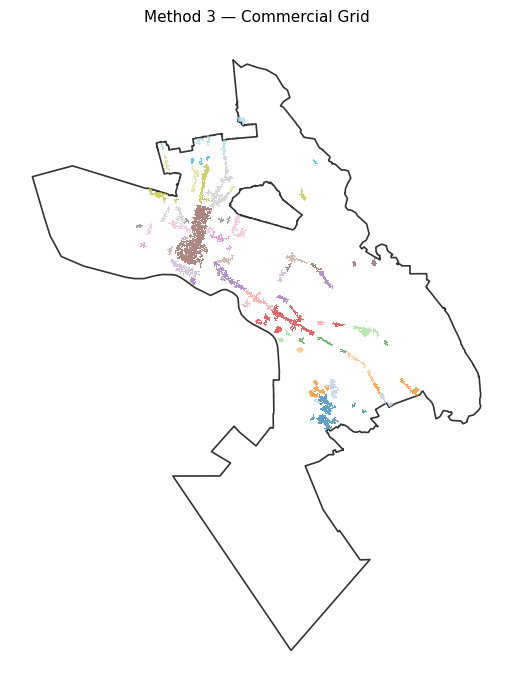

In [24]:
# ── Cell 12: Method 3 — Attach attributes, sanity check, map ──────────────────

print("Building Method 3 full attribute table...")
m3_corridors = build_corridor_attributes(
    m3_raw, union_parcels, data_axle_gdf, bids, policy,
    method="method_3_commercial_grid",
)

# Preserve Method-3-specific columns (already on m3_raw, just carry them over)
m3_specific = ["n_cells", "commercial_intensity", "corridor_score"]
for col in m3_specific:
    if col in m3_raw.columns:
        m3_corridors[col] = m3_raw.set_index("corridor_id")[col].reindex(
            m3_corridors["corridor_id"]
        ).values

# Sanity check
print_sanity_check(m3_corridors, "Method 3 — Commercial Grid")

print("Top 10 corridors by corridor_score:")
preview_cols = ["corridor_id", "area_ha", "n_cells", "n_union_parcels",
                "n_da_businesses", "commercial_intensity", "corridor_score",
                "bid_overlap_share", "policy_overlap_share"]
available = [c for c in preview_cols if c in m3_corridors.columns]
print(
    m3_corridors.nlargest(10, "corridor_score")[available]
    .to_string(index=False)
)

# ── Quick-look map ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
city_limits.plot(ax=ax, facecolor="none", edgecolor="#333333", linewidth=1.2)
m3_corridors["_color_idx"] = range(len(m3_corridors))
m3_corridors.plot(ax=ax, column="_color_idx", cmap="tab20",
                  alpha=0.7, edgecolor="none", legend=False)
m3_corridors.drop(columns=["_color_idx"], inplace=True)
ax.set_axis_off()
ax.set_title("Method 3 — Commercial Grid", fontsize=11)
plt.tight_layout()
plt.show()

In [25]:
# ── Cell 13: Cross-method comparison ──────────────────────────────────────────

def method_summary_row(corridors: gpd.GeoDataFrame, method_label: str) -> dict:
    """Summarise one method's corridors into a single-row dict."""
    area_m2 = corridors["area_m2"] if "area_m2" in corridors.columns else (corridors.geometry.area)
    return {
        "method"                  : method_label,
        "n_corridors"             : len(corridors),
        "total_area_km2"          : round(area_m2.sum() / 1e6, 2),
        "median_area_ha"          : round(area_m2.median() / 1e4, 2),
        "min_area_ha"             : round(area_m2.min() / 1e4, 2),
        "max_area_ha"             : round(area_m2.max() / 1e4, 2),
        "total_union_parcels"     : int(corridors["n_union_parcels"].sum()) if "n_union_parcels" in corridors.columns else None,
        "total_da_businesses"     : int(corridors["n_da_businesses"].sum()) if "n_da_businesses" in corridors.columns else None,
        "mean_naics_diversity"    : round(corridors["naics_diversity"].mean(), 4) if "naics_diversity" in corridors.columns else None,
        "pct_bid_overlap"         : round((corridors["bid_overlap_share"] > 0).mean() * 100, 1) if "bid_overlap_share" in corridors.columns else None,
        "pct_policy_overlap"      : round((corridors["policy_overlap_share"] > 0).mean() * 100, 1) if "policy_overlap_share" in corridors.columns else None,
        "mean_bid_overlap_share"  : round(corridors["bid_overlap_share"].mean(), 4) if "bid_overlap_share" in corridors.columns else None,
        "mean_policy_overlap_share": round(corridors["policy_overlap_share"].mean(), 4) if "policy_overlap_share" in corridors.columns else None,
    }


comparison_df = pd.DataFrame([
    method_summary_row(m1_corridors, "Method 1 — Parcel Connectivity"),
    method_summary_row(m2_corridors, "Method 2 — Seed and Grow"),
    method_summary_row(m3_corridors, "Method 3 — Commercial Grid"),
])

print("Cross-method comparison:")
print(comparison_df.to_string(index=False))

Cross-method comparison:
                        method  n_corridors  total_area_km2  median_area_ha  min_area_ha  max_area_ha  total_union_parcels  total_da_businesses  mean_naics_diversity  pct_bid_overlap  pct_policy_overlap  mean_bid_overlap_share  mean_policy_overlap_share
Method 1 — Parcel Connectivity           73           25.85            5.34         0.18       585.92                15602                22971                3.7799             13.7                19.2                  0.0595                     0.0945
      Method 2 — Seed and Grow           39           18.18           12.97         0.55       513.46                11588                17315                4.3576             28.2                35.9                  0.1825                     0.2019
    Method 3 — Commercial Grid           87           11.25            5.25         2.75       213.50                10425                20151                4.0236             21.8                32.2           

In [26]:
# ── Cell 14: Export GeoPackages and CSVs ──────────────────────────────────────

os.makedirs(OUT_DIR, exist_ok=True)

# Delete old combined GeoPackage if it exists
OLD_GPKG = os.path.join(OUT_DIR, "corridors_3_methods.gpkg")
if os.path.exists(OLD_GPKG):
    os.remove(OLD_GPKG)
    print(f"Deleted old file: {os.path.basename(OLD_GPKG)}")

# One GeoPackage per method
layers = {
    "method_1_parcel_connectivity": m1_corridors,
    "method_2_seed_and_grow"      : m2_corridors,
    "method_3_commercial_grid"    : m3_corridors,
}

print("\nWriting GeoPackages...")
for layer_name, gdf in layers.items():
    gdf_out = gdf.copy()
    if gdf_out.geometry.name != "geometry":
        gdf_out = gdf_out.rename_geometry("geometry")
    gpkg_path = os.path.join(OUT_DIR, f"{layer_name}.gpkg")
    gdf_out.to_file(gpkg_path, layer=layer_name, driver="GPKG")
    print(f"  Written: {layer_name}.gpkg  ({len(gdf_out):,} corridors)")

print("\nWriting summary CSVs...")
for layer_name, gdf in layers.items():
    csv_path = os.path.join(OUT_DIR, f"{layer_name}.csv")
    gdf.drop(columns=["geometry"]).to_csv(csv_path, index=False)
    print(f"  Written: {os.path.basename(csv_path)}")

# Cross-method comparison
comparison_csv = os.path.join(OUT_DIR, "comparison_all_methods.csv")
comparison_df.to_csv(comparison_csv, index=False)
print(f"  Written: {os.path.basename(comparison_csv)}")

print(f"\nAll outputs written to: {OUT_DIR}")

Deleted old file: corridors_3_methods.gpkg

Writing GeoPackages...
  Written: method_1_parcel_connectivity.gpkg  (73 corridors)
  Written: method_2_seed_and_grow.gpkg  (39 corridors)
  Written: method_3_commercial_grid.gpkg  (87 corridors)

Writing summary CSVs...
  Written: method_1_parcel_connectivity.csv
  Written: method_2_seed_and_grow.csv
  Written: method_3_commercial_grid.csv
  Written: comparison_all_methods.csv

All outputs written to: ../../data/corridors/260526_report/
